# Component 3 — Demand forecast: full pipeline

One notebook from data to research result. It joins (kept unchanged in `archive/`): `inventory.ipynb` (original,
monthly), `inventory_weekly.ipynb` (weekly model without leakage) and `inventory_festival_stock.ipynb`
(festival and stock analysis).

**Research question.** Can a shop's own weekly sales, with Sri Lankan festival timing, forecast next
week's demand per item better than simple rules — and when does that matter most?

| Part | What it does |
|---|---|
| A | The leakage found in the original monthly data |
| B | The weekly dataset and its lag features |
| C | Time split with a 4-week gap, time-based cross-validation |
| D | Compare five models, pick the champion, test once against naive forecasts |
| E | When does ML help? Festival and after-festival weeks |
| F | What it means for stock: lost sales and left-over stock |
| G | Reorder point (safety stock) used by the app |
| H | Training/serving check |
| I | Save the model |

**Data safety:** `shop inventory.csv` and `demand_forecast_weekly.csv` are only read.

In [1]:
import warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

def load_weekly_ordered(path):
    d = pd.read_csv(path).drop_duplicates()
    d['week_start'] = pd.to_datetime(d['iso_year'].astype(str) + '-W' + d['iso_week'].astype(str).str.zfill(2) + '-1',
                                     format='%G-W%V-%u')
    return d.sort_values(['item', 'week_start']).reset_index(drop=True)

def make_pipeline(estimator, num_cols, cat_cols=('item', 'category')):
    pre = ColumnTransformer([
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), list(cat_cols)),
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), num_cols),
    ])
    return Pipeline([('pre', pre), ('m', estimator)])

# Part A — The leakage in the original monthly data

`inventory.ipynb` trained on `shop inventory.csv` and reported R² 0.931. Its `rolling4_mean_units` is the
mean of the last four periods **including the period being predicted** — part of the answer is inside an
input. The rows are also about one month apart, while the app forecasts **weekly**.

In [2]:
old = load_weekly_ordered('shop inventory.csv').drop(columns=['target_next_month_price'], errors='ignore')
g = old.groupby('item')
incl_current = g['target_units_sold'].transform(lambda s: s.rolling(4, min_periods=1).mean())
past_only = g['target_units_sold'].transform(lambda s: s.shift(1).rolling(4, min_periods=1).mean())
print(f"rolling4_mean_units == mean INCLUDING the target period: {np.isclose(old['rolling4_mean_units'], incl_current, atol=0.51).mean():.3f}")
print(f"rolling4_mean_units == mean of PAST periods only      : {np.isclose(old['rolling4_mean_units'], past_only, atol=0.51).mean():.3f}")
print('Weeks between rows of an item:', (g['week_start'].diff().dt.days / 7).value_counts().head(3).to_dict())

fixed = old.copy()
fixed['rolling4_mean_units'] = past_only
fixed['rolling4_mean_price'] = g['avg_retail_price_rs'].transform(lambda s: s.shift(1).rolling(4, min_periods=1).mean())
train = old['iso_year'] < 2024          # same split as inventory.ipynb
leak_rows = []
for label, data in [('as trained (leak)', old), ('leak removed', fixed)]:
    Xo = data.drop(columns=['target_units_sold', 'week_start']); yo = data['target_units_sold']
    num = [c for c in Xo.columns if c not in ('item', 'category')]
    m = make_pipeline(RandomForestRegressor(n_estimators=300, max_depth=12, n_jobs=-1, random_state=RANDOM_STATE), num)
    p = m.fit(Xo[train], yo[train]).predict(Xo[~train])
    leak_rows.append({'shop inventory.csv': label, 'MAE': mean_absolute_error(yo[~train], p), 'R²': r2_score(yo[~train], p)})
pd.DataFrame(leak_rows).set_index('shop inventory.csv').round(3)

rolling4_mean_units == mean INCLUDING the target period: 1.000
rolling4_mean_units == mean of PAST periods only      : 0.044
Weeks between rows of an item: {4.0: 1508, 5.0: 833, 13.0: 16}


,MAE,R²
shop inventory.csv,,
as trained (leak),21.557,0.931
leak removed,26.916,0.889


Without the leak the same model drops from R² ≈ 0.93 to ≈ 0.89. The 0.931 must not be reported as accuracy.

# Part B — The weekly dataset

In [3]:
df = load_weekly_ordered('demand_forecast_weekly.csv')
g = df.groupby('item')
print(f"{len(df)} rows | {df['item'].nunique()} items | {df['week_start'].min().date()} -> {df['week_start'].max().date()}")
print('Weeks between rows:', (g['week_start'].diff().dt.days / 7).value_counts().head(3).to_dict())
checks = {
    'lag1_units == units last week': (df['lag1_units'], g['target_units_sold'].shift(1)),
    'lag4_units == units 4 weeks ago': (df['lag4_units'], g['target_units_sold'].shift(4)),
    'rolling4_mean_units == mean of the 4 PAST weeks': (df['rolling4_mean_units'],
        g['target_units_sold'].transform(lambda s: s.shift(1).rolling(4, min_periods=1).mean())),
}
for name, (a, b) in checks.items():
    m = a.notna() & b.notna()
    print(f'{name:48s}: {np.isclose(a[m], b[m], atol=0.51).mean():.3f}')
print('weekend_share values:', df['weekend_share'].value_counts().to_dict())

5434 rows | 26 items | 2022-06-13 -> 2026-06-08
Weeks between rows: {1.0: 5408}
lag1_units == units last week                   : 1.000
lag4_units == units 4 weeks ago                 : 1.000
rolling4_mean_units == mean of the 4 PAST weeks : 1.000
weekend_share values: {0.29: 5408, 0.0: 26}


All lag features use **past weeks only** — the same definitions the app uses. `weekend_share` is almost
constant, so it carries no information (kept only because the app sends it).

# Part C — Time split with a 4-week gap

In [4]:
X = df.drop(columns=['target_units_sold', 'week_start'])
y = df['target_units_sold'].astype(float)
num_cols = [c for c in X.columns if c not in ('item', 'category')]
GAP = pd.Timedelta(weeks=4)
TEST_START = pd.Timestamp('2025-07-01')
dev = (df['week_start'] < TEST_START - GAP).values
test = (df['week_start'] >= TEST_START).values
X_dev, y_dev, X_test, y_test = X[dev], y[dev], X[test], y[test]
print(f"Development: {dev.sum()} rows (-> {df.loc[dev, 'week_start'].max().date()}) | gap: {(~dev & ~test).sum()} | "
      f"test: {test.sum()} rows ({df.loc[test, 'week_start'].min().date()} -> {df.loc[test, 'week_start'].max().date()})")
dev_weeks = df.loc[dev, 'week_start'].reset_index(drop=True)
cuts = pd.date_range(dev_weeks.min() + pd.Timedelta(weeks=52), dev_weeks.max(), periods=5)
time_folds = [(np.where(dev_weeks < a - GAP)[0], np.where((dev_weeks >= a) & (dev_weeks < b))[0]) for a, b in zip(cuts[:-1], cuts[1:])]
for i, (tr, va) in enumerate(time_folds, 1):
    print(f'Fold {i}: train {len(tr)} rows -> validate {dev_weeks.iloc[va].min().date()} .. {dev_weeks.iloc[va].max().date()} ({len(va)})')

Development: 4056 rows (-> 2025-06-02) | gap: 104 | test: 1274 rows (2025-07-07 -> 2026-06-08)
Fold 1: train 1248 rows -> validate 2023-06-12 .. 2023-12-04 (676)
Fold 2: train 1924 rows -> validate 2023-12-11 .. 2024-06-03 (676)
Fold 3: train 2600 rows -> validate 2024-06-10 .. 2024-12-02 (676)
Fold 4: train 3276 rows -> validate 2024-12-09 .. 2025-05-26 (650)


# Part D — Model comparison (MAE in units per item per week, lower is better)

In [5]:
estimators = {
    'LinearRegression': LinearRegression(),
    'DecisionTree': DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
    'RandomForest': RandomForestRegressor(n_estimators=300, max_depth=12, n_jobs=-1, random_state=RANDOM_STATE),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=250, learning_rate=0.05, max_depth=5, random_state=RANDOM_STATE),
    'XGBoost': XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.9, random_state=RANDOM_STATE),
}
cv_rows = {}
for name, est in estimators.items():
    maes = [mean_absolute_error(y_dev.iloc[va], make_pipeline(clone(est), num_cols).fit(X_dev.iloc[tr], y_dev.iloc[tr]).predict(X_dev.iloc[va]))
            for tr, va in time_folds]
    cv_rows[name] = {'time-CV MAE': np.mean(maes), '± std': np.std(maes)}
cv_table = pd.DataFrame(cv_rows).T.round(2)
best_name = cv_table['time-CV MAE'].idxmin()
print(f'Champion (validation folds only): {best_name}')
cv_table

Champion (validation folds only): RandomForest


,time-CV MAE,± std
LinearRegression,11.43,2.01
DecisionTree,9.96,1.80
RandomForest,9.88,2.03
GradientBoosting,10.03,1.83
XGBoost,10.19,1.71


## D2. Test once on the future period, against naive forecasts

In [6]:
model = make_pipeline(clone(estimators[best_name]), num_cols).fit(X_dev, y_dev)
pred = model.predict(X_test)
forecasts = {f'ML: {best_name}': pred, 'Naive: same as last week': X_test['lag1_units'].values,
             'Naive: mean of past 4 weeks': X_test['rolling4_mean_units'].values}
results = pd.DataFrame({k: {'MAE': mean_absolute_error(y_test, v), 'RMSE': np.sqrt(mean_squared_error(y_test, v)),
                            'R²': r2_score(y_test, v)} for k, v in forecasts.items()}).T
test_mae, test_rmse, test_r2 = results.iloc[0]
best_naive = results.iloc[1:]['MAE'].min()
print(f'ML MAE is {(1 - test_mae / best_naive) * 100:.1f}% lower than the best naive forecast')
results.round(3)

ML MAE is 21.7% lower than the best naive forecast


,MAE,RMSE,R²
ML: RandomForest,10.89,24.786,0.908
Naive: same as last week,13.90,30.489,0.861
Naive: mean of past 4 weeks,14.15,31.157,0.855


# Part E — When does ML help?

Demand jumps around Sinhala and Tamil New Year (Avurudu). "Same as last week" only reacts *after* the jump.
Test weeks are labelled festival (`festival_season = 1`), after-festival (the 2 weeks after) and normal.

In [7]:
T = df[test].copy()
T['ML'] = pred; T['Naive: last week'] = T['lag1_units']; T['Naive: 4-week mean'] = T['rolling4_mean_units']
METHODS = ['ML', 'Naive: last week', 'Naive: 4-week mean']
fest_weeks = sorted(T.loc[T['festival_season'] == 1, 'week_start'].unique())
after_weeks = [fest_weeks[-1] + pd.Timedelta(weeks=k) for k in (1, 2)]
T['period'] = np.select([T['week_start'].isin(fest_weeks), T['week_start'].isin(after_weeks)], ['festival', 'after festival'], 'normal')
print('Festival weeks:', [str(w.date()) for w in fest_weeks], '| after:', [str(w.date()) for w in after_weeks])

rows = []
for period in ['normal', 'festival', 'after festival', 'ALL']:
    part = T if period == 'ALL' else T[T['period'] == period]
    row = {'period': period, 'rows': len(part)}
    for m in METHODS: row[f'MAE {m}'] = float(np.mean(np.abs(part['target_units_sold'] - part[m])))
    row['ML better than best naive %'] = (1 - row['MAE ML'] / min(row['MAE Naive: last week'], row['MAE Naive: 4-week mean'])) * 100
    rows.append(row)
by_period = pd.DataFrame(rows).set_index('period').round(2)
by_period

Festival weeks: ['2026-03-30', '2026-04-06', '2026-04-13'] | after: ['2026-04-20', '2026-04-27']


,rows,MAE ML,MAE Naive: last week,MAE Naive: 4-week mean,ML better than best naive %
period,,,,,
normal,1144,9.89,11.99,11.62,14.88
festival,78,25.98,32.54,39.00,20.16
after festival,52,10.16,28.04,32.47,63.75
ALL,1274,10.89,13.90,14.15,21.66


In [8]:
rng = np.random.default_rng(RANDOM_STATE)
for period in ['normal', 'festival', 'after festival', 'ALL']:
    part = T if period == 'ALL' else T[T['period'] == period]
    a = part['target_units_sold'].to_numpy(); err = {m: np.abs(a - part[m].to_numpy()) for m in METHODS}
    naive = min(['Naive: last week', 'Naive: 4-week mean'], key=lambda m: err[m].mean())
    idx = rng.integers(0, len(a), size=(1000, len(a)))
    gain = err[naive][idx].mean(1) - err['ML'][idx].mean(1); lo, hi = np.percentile(gain, [2.5, 97.5])
    print(f'{period:15s} vs {naive:18s}: ML better by {gain.mean():5.2f} units/week  95% CI [{lo:5.2f}, {hi:5.2f}]')

normal          vs Naive: 4-week mean: ML better by  1.73 units/week  95% CI [ 1.00,  2.51]
festival        vs Naive: last week  : ML better by  6.29 units/week  95% CI [-1.93, 15.29]
after festival  vs Naive: last week  : ML better by 17.66 units/week  95% CI [ 9.68, 27.29]
ALL             vs Naive: last week  : ML better by  3.03 units/week  95% CI [ 1.89,  4.10]


Above 0 means ML is better. The festival periods have only a few weeks, so their intervals are wide.

# Part F — What it means for stock

If the shop stocks exactly the forecast each week: **short** = units wanted but not on the shelf (lost sales);
**left over** = units bought but not sold that week (money tied up, spoilage for fresh produce).

In [9]:
actual = T['target_units_sold']; srows = []
for m in METHODS:
    short = np.maximum(0, actual - T[m]); over = np.maximum(0, T[m] - actual)
    for period in ['festival', 'after festival', 'ALL']:
        mask = np.ones(len(T), bool) if period == 'ALL' else (T['period'] == period).to_numpy()
        srows.append({'period': period, 'method': m,
                      'short % of demand': short[mask].sum() / actual[mask].sum() * 100,
                      'left-over % of demand': over[mask].sum() / actual[mask].sum() * 100})
stock = pd.DataFrame(srows).set_index(['period', 'method']).sort_index().round(1)
stock

short % of demand  left-over % of demand
period         method                                                      
ALL            ML                                9.3                    7.0
               Naive: 4-week mean               10.2                   11.1
               Naive: last week                  9.9                   10.9
after festival ML                                8.1                    7.1
               Naive: 4-week mean                0.5                   48.1
               Naive: last week                  2.5                   39.5
festival       ML                               10.9                   12.9
               Naive: 4-week mean               34.1                    1.6
               Naive: last week                 22.6                    7.2

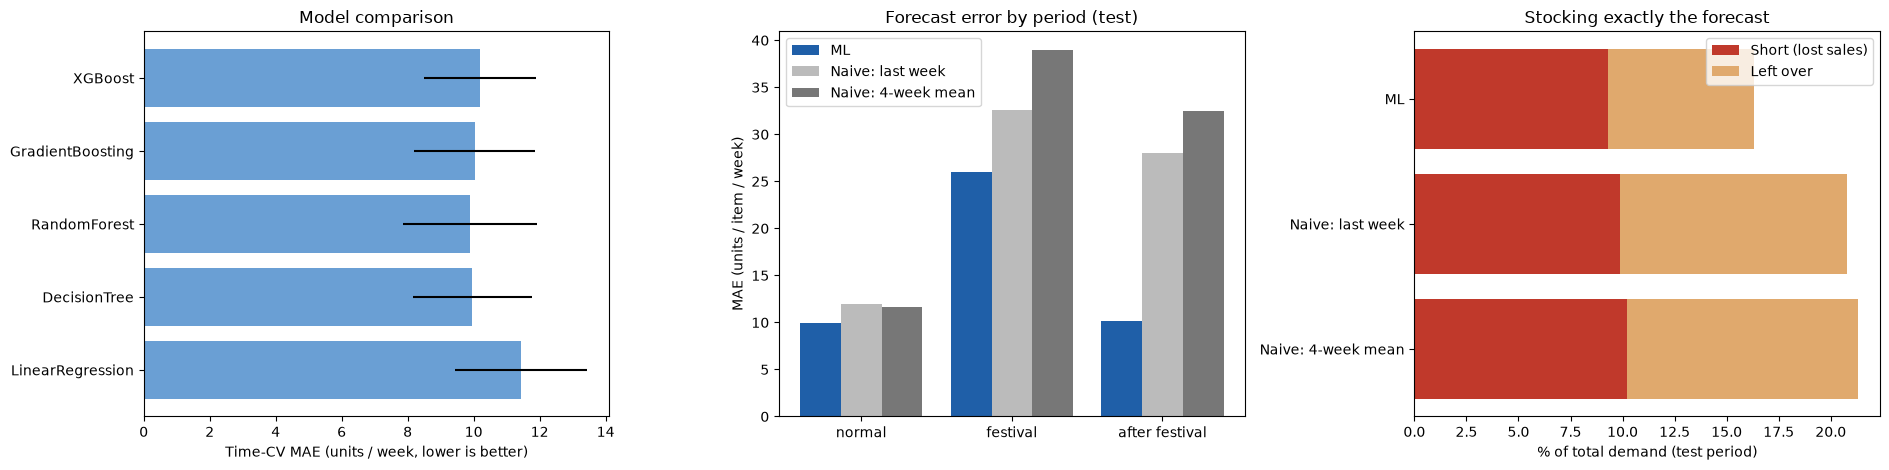

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(19, 4.8))
ax[0].barh(cv_table.index, cv_table['time-CV MAE'], xerr=cv_table['± std'], color='#6a9fd4')
ax[0].set_xlabel('Time-CV MAE (units / week, lower is better)'); ax[0].set_title('Model comparison')
periods = ['normal', 'festival', 'after festival']; x = np.arange(3); w = 0.27
colors = {'ML': '#1f5fa8', 'Naive: last week': '#bbb', 'Naive: 4-week mean': '#777'}
for i, m in enumerate(METHODS):
    ax[1].bar(x + (i - 1) * w, by_period.loc[periods, f'MAE {m}'], w, label=m, color=colors[m])
ax[1].set_xticks(x); ax[1].set_xticklabels(periods); ax[1].set_ylabel('MAE (units / item / week)')
ax[1].set_title('Forecast error by period (test)'); ax[1].legend()
s = stock.xs('ALL', level='period').loc[METHODS]
ax[2].barh(METHODS, s['short % of demand'], color='#c0392b', label='Short (lost sales)')
ax[2].barh(METHODS, s['left-over % of demand'], left=s['short % of demand'], color='#e0a96d', label='Left over')
ax[2].invert_yaxis(); ax[2].set_xlabel('% of total demand (test period)'); ax[2].set_title('Stocking exactly the forecast')
ax[2].legend(loc='upper right')
plt.tight_layout(); plt.savefig('weekly_demand_forecast_pipeline.png', dpi=120); plt.show()

# Part G — Reorder point used by the app

`reorder point = forecast per week × lead time (weeks) + Z × RMSE × √(lead time in weeks)`, Z = 1.65
(about 95 % chance of not running out before the delivery arrives). The app uses this to decide **Buy / Wait**
(`forecastReorderLevel` in `backend/src/utils/features.js`, with the test RMSE below).

In [11]:
Z = 1.65
print(f'Test RMSE used for safety stock: {test_rmse:.2f} units/week')
def reorder_point(forecast_per_week, lead_time_days):
    weeks = max(lead_time_days, 1) / 7
    safety = Z * test_rmse * np.sqrt(weeks)
    return round(forecast_per_week * weeks + safety), round(safety)
for lt in (1, 3, 7, 14):
    level, safety = reorder_point(float(np.median(pred)), lt)
    print(f'lead time {lt:2d} days: buy when stock < {level} units (safety stock {safety})')

Test RMSE used for safety stock: 24.79 units/week
lead time  1 days: buy when stock < 22 units (safety stock 15)
lead time  3 days: buy when stock < 45 units (safety stock 27)
lead time  7 days: buy when stock < 84 units (safety stock 41)
lead time 14 days: buy when stock < 144 units (safety stock 58)


# Part H — Training/serving check

The app builds the inputs in `buildDemandFeatures` (`backend/src/utils/features.js`) from the shop's own
weekly sales: `lag1_units`, `lag4_units`, `rolling4_mean_units` — same definitions as Part B.
One definition is checked here: **when is it "festival season"?**

In [12]:
f = df[df['festival_season'] == 1]['days_to_avurudu']; n = df[df['festival_season'] == 0]['days_to_avurudu']
print(f'In this data festival_season = 1 when days_to_avurudu is {f.min()}..{f.max()}; 0 from {n.min()} days')

In this data festival_season = 1 when days_to_avurudu is 0..21; 0 from 22 days


The backend first used "30 days or less" for both demand and procurement. That labels days 22–30 before
Avurudu as festival although the model never saw them that way. The backend now uses **21 days** for the
demand model, matching this data (the procurement data uses its own definition).

# Part I — Save the model

Refit the champion on **all** weeks; checked against the app's copy (`ml_service/models/weekly_demand_forecast_model.pkl`).

In [13]:
final_model = make_pipeline(clone(estimators[best_name]), num_cols).fit(X, y)
try:
    deployed = joblib.load('../../ml_service/models/weekly_demand_forecast_model.pkl')
    diff = np.abs(deployed.predict(X) - final_model.predict(X)).max()
    print(f'Largest difference from the model the app uses: {diff:.6f}', '(same model)' if diff < 1e-6 else '(different)')
except Exception as e:
    print('Deployed model not checked:', e)
joblib.dump(final_model, 'weekly_demand_forecast_model.pkl', compress=3)
print('Saved weekly_demand_forecast_model.pkl', {'champion': best_name, 'test_mae': round(test_mae, 2),
      'test_rmse': round(test_rmse, 2), 'test_r2': round(test_r2, 3)})

Largest difference from the model the app uses: 0.000000 (same model)
Saved component3_demand_forecast_full_pipeline.pkl {'champion': 'RandomForest', 'test_mae': 10.89, 'test_rmse': 24.79, 'test_r2': 0.908}


# Conclusion

*Written after reading the numbers above — fill in with the actual results:*

- The original R² 0.931 was inflated by leakage; without it ___.
- Weekly champion ___: test MAE ___ units, ___ % better than the best naive forecast (interval ___).
- After Avurudu: ML ___ % better; stocking the ML forecast leaves ___ % over vs ___ % for "same as last week".

**Limitations.** The test period has one Avurudu (3 festival weeks, 2 after), so the festival results are
indicative. The weekly series is not one real shop's sales. The safety stock uses one error figure for all
items, so it is relatively large for slow-selling items.